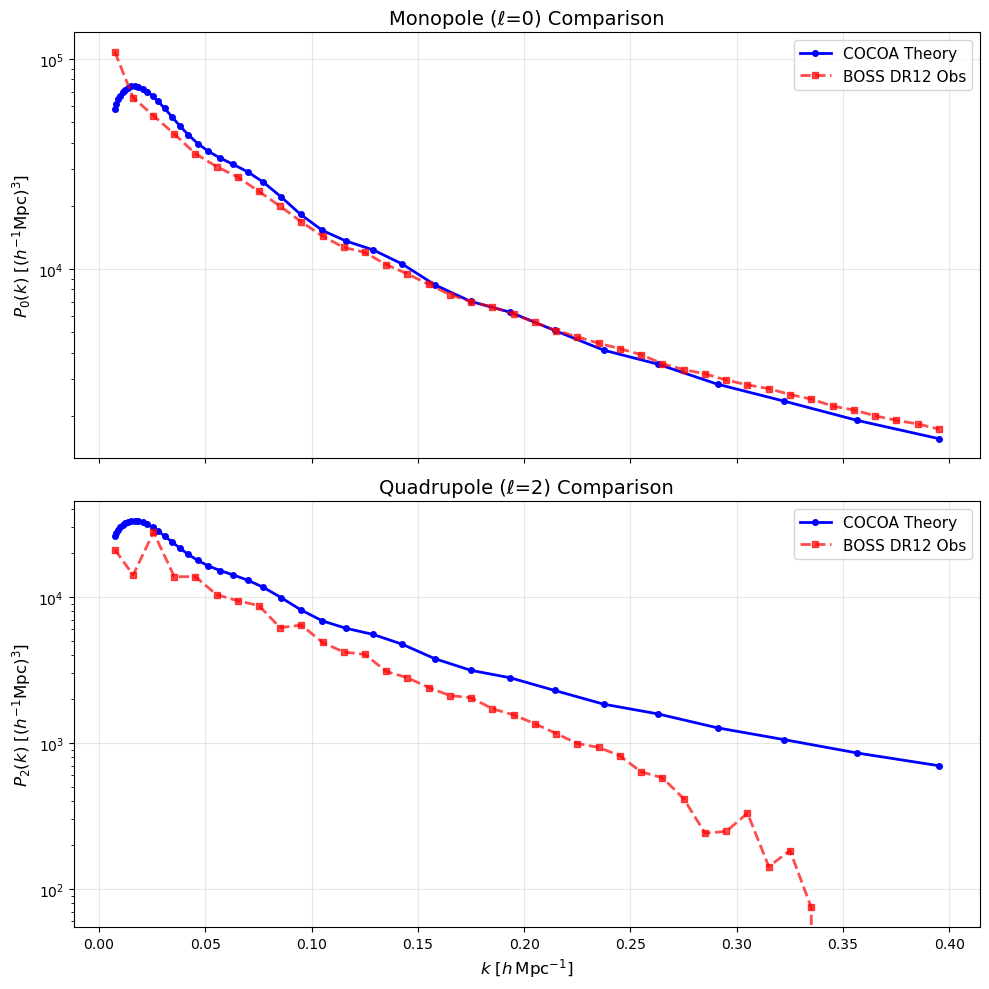

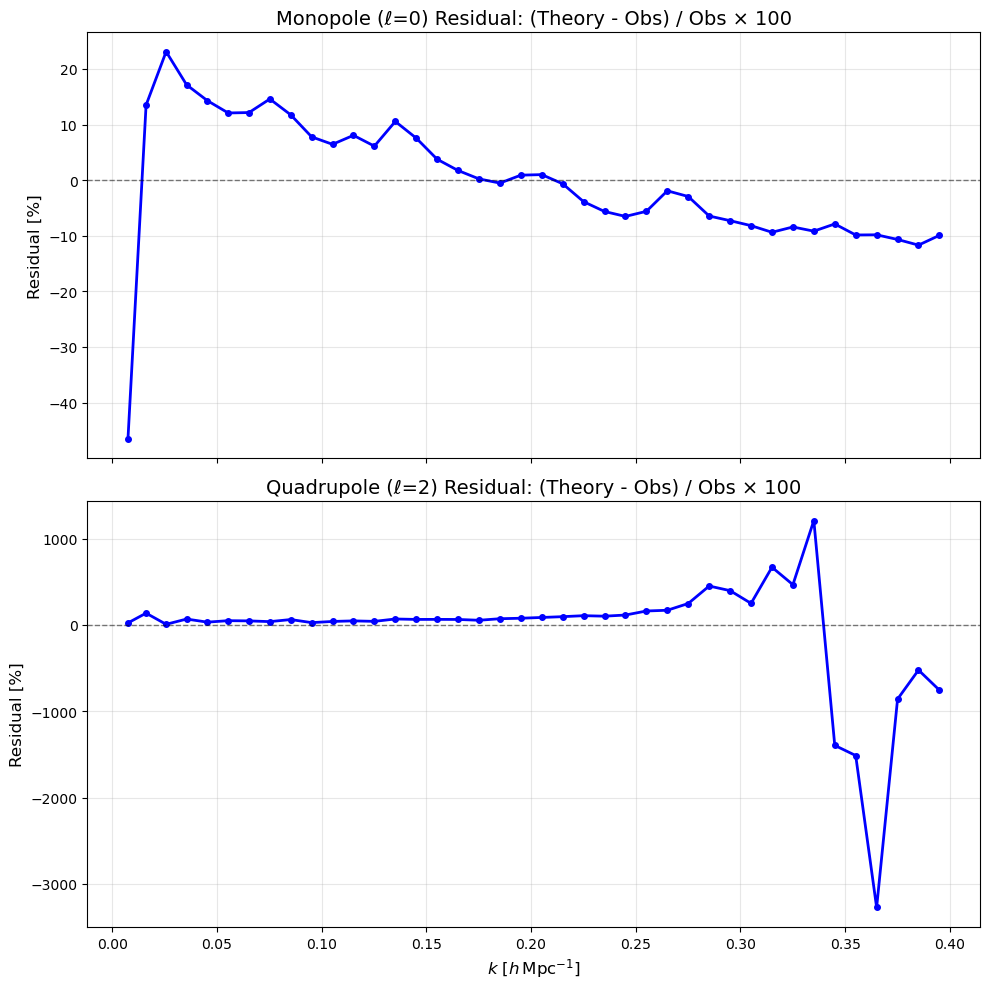

=== 統計情報 ===

Monopole (P0):
  Theory range: [1.56e+03, 7.43e+04]
  Obs range: [1.73e+03, 1.08e+05]
  Mean residual: -0.25%
  RMS residual: 11.79%

Quadrupole (P2):
  Theory range: [6.99e+02, 3.33e+04]
  Obs range: [-1.72e+02, 2.77e+04]
  Mean residual: -67.89%
  RMS residual: 695.13%


In [43]:
"""
COCOAで計算したmonopoleとquadrupoleをBOSS DR12の観測データと比較してプロット
Notebookにコピペして使用
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline as iuspline


# ===== 設定 =====
# ファイルパス（必要に応じて変更）
data_dir = "./"
theory_file = data_dir + "mg_hsc_y3_theory_kaiser_rsd_boss_dr12.modelvector"
obs_file = data_dir + "boss_dr12_cmass_datavector.txt"
boss_original_file = data_dir + "Power_Spectrum_cmass_ngc_v5.txt"  # kの値を取得するため

# データ読み込み
# COCOA理論値（chunked形式: 最初の40個がmonopole、次の40個がquadrupole）
theory_data = np.loadtxt(theory_file)
theory_indices = theory_data[:, 0].astype(int)
theory_values = theory_data[:, 1]




# BOSS DR12観測データ（chunked形式: 最初の40個がmonopole、次の40個がquadrupole）
obs_data = np.loadtxt(obs_file)
obs_indices = obs_data[:, 0].astype(int)
obs_values = obs_data[:, 1]


# kの値を取得（元のBOSS DR12ファイルから）
k_eff = []
P0 = []
P2 = []

with open(boss_original_file, 'r') as f:
    for line in f:
        if line.startswith('#') or len(line.strip()) == 0:
            continue
        parts = line.split()
        if len(parts) >= 2:
            try:
                k_eff.append(float(parts[1]))  # k-eff列
                P0.append(float(parts[2]))
                P2.append(float(parts[3]))
            except ValueError:
                continue

# k_eff = np.array(k_eff[:40])  # 最初の40個のkビン
# P0 = np.array(P0[:40])  # 最初の40個のkビン
# P2 = np.array(P2[:40])  # 最初の40個のkビン

# データをmonopoleとquadrupoleに分離
Nk = 40
theory_p0 = theory_values[:Nk] 
theory_p2 = theory_values[Nk:]
obs_p0 = obs_values[:Nk]
obs_p2 = obs_values[Nk:]

# プロット
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Monopole (P0)
ax = axes[0]
# ax.plot(k_eff, theory_p0, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.plot(k_bins_cocoa, theory_p0, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.plot(k_eff, obs_p0, 'r--', label='BOSS DR12 Obs', linewidth=2, marker='s', markersize=4, alpha=0.7)
# ax.plot(k_eff, P0, 'b--', label='BOSS DR12 Obs_2', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax.set_ylabel(r'$P_0(k)$ [$(h^{-1}\mathrm{Mpc})^3$]', fontsize=12)
ax.set_title('Monopole (ℓ=0) Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Quadrupole (P2)
ax = axes[1]
# ax.plot(k_eff, theory_p2, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.plot(k_bins_cocoa, theory_p2, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.plot(k_eff, obs_p2, 'r--', label='BOSS DR12 Obs', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax.set_xlabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_ylabel(r'$P_2(k)$ [$(h^{-1}\mathrm{Mpc})^3$]', fontsize=12)
ax.set_title('Quadrupole (ℓ=2) Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# 残差プロット
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Monopole残差
ax = axes[0]
# residual_p0 = (theory_p0 - obs_p0) / obs_p0 * 100  # パーセント残差
residual_p0 = (iuspline(k_bins_cocoa, theory_p0)(k_eff) - obs_p0) / obs_p0 * 100  # パーセント残差
ax.plot(k_eff, residual_p0, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel(r'Residual [%]', fontsize=12)
ax.set_title('Monopole (ℓ=0) Residual: (Theory - Obs) / Obs × 100', fontsize=14)
ax.grid(True, alpha=0.3)

# Quadrupole残差
ax = axes[1]
# residual_p2 = (theory_p2 - obs_p2) / obs_p2 * 100  # パーセント残差
residual_p2 = (iuspline(k_bins_cocoa, theory_p2)(k_eff) - obs_p2) / obs_p2 * 100  # パーセント残差
ax.plot(k_eff, residual_p2, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_ylabel(r'Residual [%]', fontsize=12)
ax.set_title('Quadrupole (ℓ=2) Residual: (Theory - Obs) / Obs × 100', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 統計情報を表示
print("=== 統計情報 ===")
print(f"\nMonopole (P0):")
print(f"  Theory range: [{theory_p0.min():.2e}, {theory_p0.max():.2e}]")
print(f"  Obs range: [{obs_p0.min():.2e}, {obs_p0.max():.2e}]")
print(f"  Mean residual: {residual_p0.mean():.2f}%")
print(f"  RMS residual: {np.sqrt(np.mean(residual_p0**2)):.2f}%")

print(f"\nQuadrupole (P2):")
print(f"  Theory range: [{theory_p2.min():.2e}, {theory_p2.max():.2e}]")
print(f"  Obs range: [{obs_p2.min():.2e}, {obs_p2.max():.2e}]")
print(f"  Mean residual: {residual_p2.mean():.2f}%")
print(f"  RMS residual: {np.sqrt(np.mean(residual_p2**2)):.2f}%")



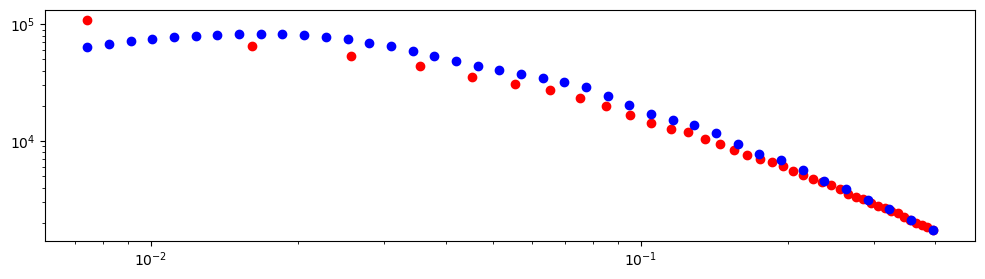

In [40]:
# k_eff = np.array(k_eff[:40])  # 最初の40個のkビン
# P0 = np.array(P0[:40])  # 最初の40個のkビン
# P2 = np.array(P2[:40])  # 最初の40個のkビン

plt.figure(figsize = (12,3))
plt.scatter(k_eff, P0, color = "r")
plt.scatter(k_bins_cocoa, theory_p0, color = "b")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0.02, 0.24)

(0.02, 0.24)

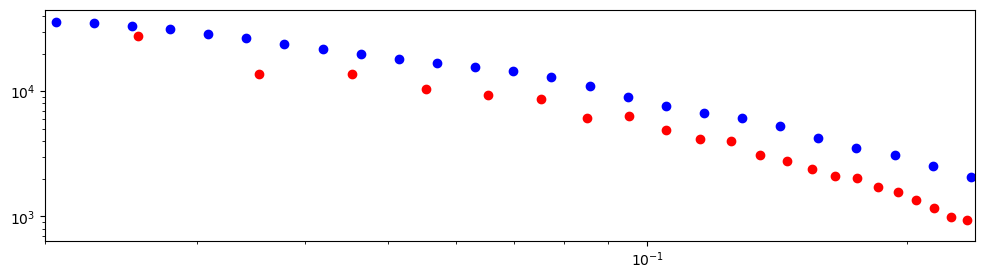

In [39]:
plt.figure(figsize = (12,3))
plt.scatter(k_eff, P2, color = "r")
plt.scatter(k_bins_cocoa, theory_p2, color = "b")
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.02, 0.24)

In [32]:
Nk = 40
k_min = 0.007424
k_max = 0.395040

# np.logspace は「10の何乗」から「10の何乗」までを指定する
# そのため、引数には k_min, k_max の log10 を渡す
k_bins_cocoa = np.logspace(
    np.log10(k_min),  # 開始値 (10**X の X)
    np.log10(k_max),  # 終了値 (10**Y の Y)
    Nk                # 要素数
)
print(k_bins_cocoq)

[0.007424   0.00822043 0.0091023  0.01007877 0.01115999 0.01235721
 0.01368286 0.01515072 0.01677606 0.01857575 0.02056851 0.02277505
 0.0252183  0.02792366 0.03091924 0.03423618 0.03790895 0.04197573
 0.04647879 0.05146492 0.05698595 0.06309926 0.06986839 0.0773637
 0.08566309 0.09485281 0.10502839 0.11629558 0.12877148 0.14258577
 0.15788202 0.17481921 0.19357338 0.21433946 0.23733327 0.2627938
 0.29098567 0.3222019  0.35676692 0.39504   ]


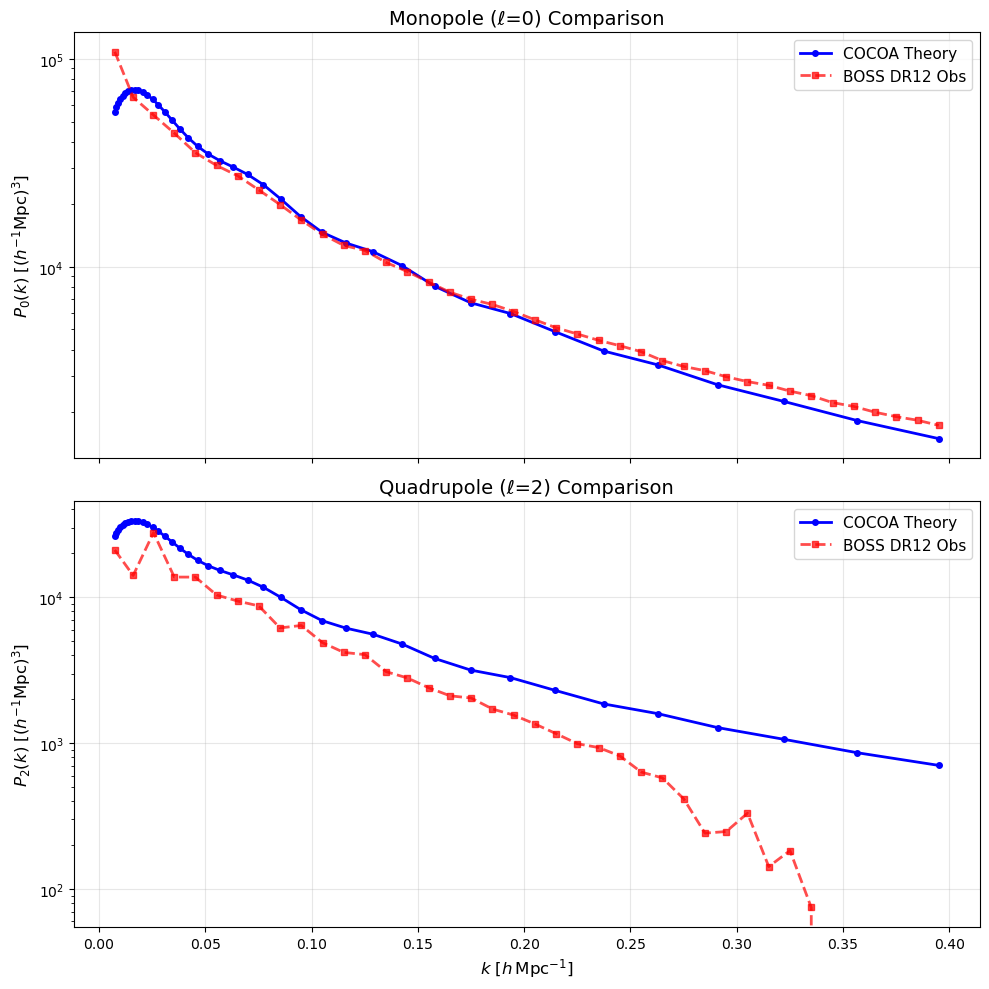

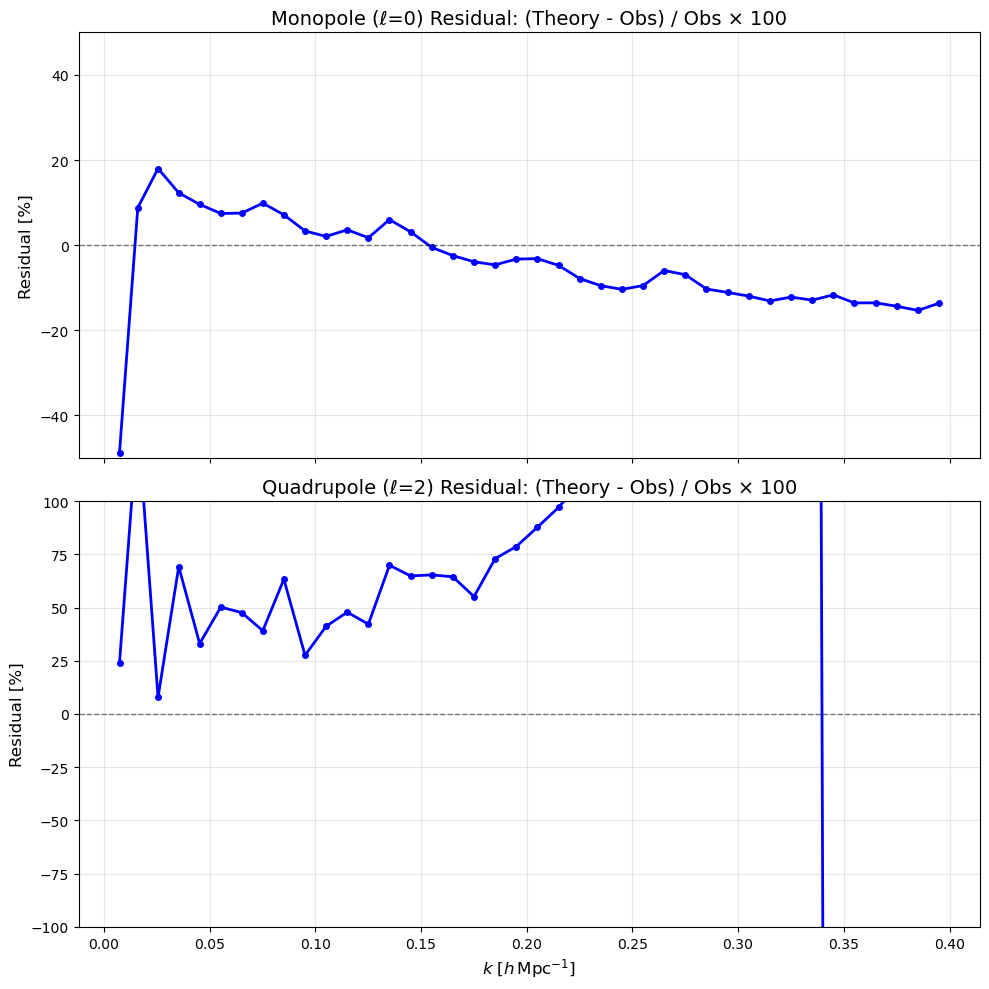

=== 統計情報 ===

Monopole (P0):
  Theory range: [1.49e+03, 7.12e+04]
  Obs range: [1.73e+03, 1.08e+05]
  Mean residual: -4.37%
  RMS residual: 12.11%

Quadrupole (P2):
  Theory range: [7.04e+02, 3.36e+04]
  Obs range: [-1.72e+02, 2.77e+04]
  Mean residual: -67.66%
  RMS residual: 700.20%

=== kビンの比較 ===
COCOA kビン数: 40
BOSS k-eff数: 40
COCOA k範囲: [0.007424, 0.395040]
BOSS k範囲: [0.007424, 0.395040]


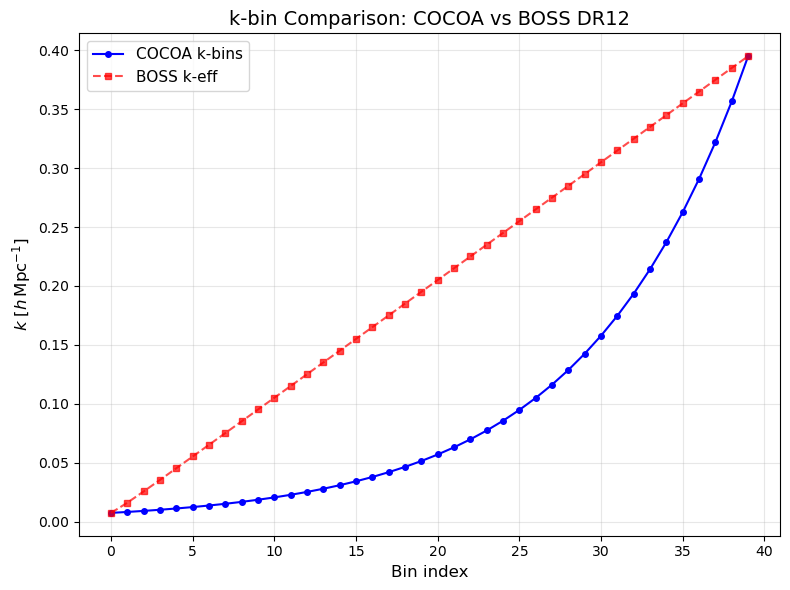

In [4]:
"""

COCOAで計算したmonopoleとquadrupoleをBOSS DR12の観測データと比較してプロット

Notebookにコピペして使用

修正点:
- k_bins_cocoaの定義を追加
- k値の対応関係を明確に
- 残差計算の補間を修正

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline as iuspline

# ===== COCOAのkビン計算関数 =====
def calculate_cocoa_k_bins(k_min, k_max, Nk):
    """COCOAの対数等間隔kビンを計算"""
    log_dk = (np.log10(k_max) - np.log10(k_min)) / (Nk - 1)
    k_bins = np.array([10**(np.log10(k_min) + i * log_dk) for i in range(Nk)])
    return k_bins

# ===== 設定 =====
# ファイルパス（必要に応じて変更）
data_dir = "./"
theory_file = data_dir + "mg_hsc_y3_theory_kaiser_rsd_boss_dr12.modelvector"
obs_file = data_dir + "boss_dr12_cmass_datavector.txt"
boss_original_file = data_dir + "Power_Spectrum_cmass_ngc_v5.txt"  # kの値を取得するため

# ===== データ読み込み =====
# COCOA理論値（chunked形式: 最初の40個がmonopole、次の40個がquadrupole）
theory_data = np.loadtxt(theory_file)
theory_indices = theory_data[:, 0].astype(int)
theory_values = theory_data[:, 1]

# BOSS DR12観測データ（chunked形式: 最初の40個がmonopole、次の40個がquadrupole）
obs_data = np.loadtxt(obs_file)
obs_indices = obs_data[:, 0].astype(int)
obs_values = obs_data[:, 1]

# ===== k値の取得 =====
# COCOAのkビン（対数等間隔）
k_min = 0.007424
k_max = 0.395040
Nk = 40
k_bins_cocoa = calculate_cocoa_k_bins(k_min, k_max, Nk)

# BOSS DR12のk-eff値を取得
k_eff = []
P0_boss_orig = []
P2_boss_orig = []

with open(boss_original_file, 'r') as f:
    for line in f:
        if line.startswith('#') or len(line.strip()) == 0:
            continue
        parts = line.split()
        if len(parts) >= 4:
            try:
                k_eff.append(float(parts[1]))  # k-eff列
                P0_boss_orig.append(float(parts[2]))  # Monopole-Pshotnoise
                P2_boss_orig.append(float(parts[3]))  # Quadrupole
            except ValueError:
                continue

k_eff = np.array(k_eff)
P0_boss_orig = np.array(P0_boss_orig)
P2_boss_orig = np.array(P2_boss_orig)

# ===== データ分割 =====
# データをmonopoleとquadrupoleに分離
theory_p0 = theory_values[:Nk] 
theory_p2 = theory_values[Nk:2*Nk]
obs_p0 = obs_values[:Nk]
obs_p2 = obs_values[Nk:2*Nk]

# ===== プロット =====
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Monopole (P0)
ax = axes[0]
ax.plot(k_bins_cocoa, theory_p0, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.plot(k_eff, obs_p0, 'r--', label='BOSS DR12 Obs', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax.set_ylabel(r'$P_0(k)$ [$(h^{-1}\mathrm{Mpc})^3$]', fontsize=12)
ax.set_title('Monopole (ℓ=0) Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Quadrupole (P2)
ax = axes[1]
ax.plot(k_bins_cocoa, theory_p2, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.plot(k_eff, obs_p2, 'r--', label='BOSS DR12 Obs', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax.set_xlabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_ylabel(r'$P_2(k)$ [$(h^{-1}\mathrm{Mpc})^3$]', fontsize=12)
ax.set_title('Quadrupole (ℓ=2) Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# ===== 残差プロット =====
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Monopole残差
ax = axes[0]
# 残差計算: COCOA理論をBOSSのkに補間してから比較
residual_p0 = (iuspline(k_bins_cocoa, theory_p0)(k_eff) - obs_p0) / obs_p0 * 100
ax.plot(k_eff, residual_p0, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel(r'Residual [%]', fontsize=12)
ax.set_title('Monopole (ℓ=0) Residual: (Theory - Obs) / Obs × 100', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim([-50, 50])  # 適宜調整

# Quadrupole残差
ax = axes[1]
residual_p2 = (iuspline(k_bins_cocoa, theory_p2)(k_eff) - obs_p2) / obs_p2 * 100
ax.plot(k_eff, residual_p2, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_ylabel(r'Residual [%]', fontsize=12)
ax.set_title('Quadrupole (ℓ=2) Residual: (Theory - Obs) / Obs × 100', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim([-100, 100])  # 適宜調整

plt.tight_layout()
plt.show()

# ===== 統計情報を表示 =====
print("=== 統計情報 ===")
print(f"\nMonopole (P0):")
print(f"  Theory range: [{theory_p0.min():.2e}, {theory_p0.max():.2e}]")
print(f"  Obs range: [{obs_p0.min():.2e}, {obs_p0.max():.2e}]")
print(f"  Mean residual: {residual_p0.mean():.2f}%")
print(f"  RMS residual: {np.sqrt(np.mean(residual_p0**2)):.2f}%")

print(f"\nQuadrupole (P2):")
print(f"  Theory range: [{theory_p2.min():.2e}, {theory_p2.max():.2e}]")
print(f"  Obs range: [{obs_p2.min():.2e}, {obs_p2.max():.2e}]")
print(f"  Mean residual: {residual_p2.mean():.2f}%")
print(f"  RMS residual: {np.sqrt(np.mean(residual_p2**2)):.2f}%")

# ===== 追加: kビンの比較 =====
print(f"\n=== kビンの比較 ===")
print(f"COCOA kビン数: {len(k_bins_cocoa)}")
print(f"BOSS k-eff数: {len(k_eff)}")
print(f"COCOA k範囲: [{k_bins_cocoa.min():.6f}, {k_bins_cocoa.max():.6f}]")
print(f"BOSS k範囲: [{k_eff.min():.6f}, {k_eff.max():.6f}]")

# kビンの違いをプロット
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(range(len(k_bins_cocoa)), k_bins_cocoa, 'bo-', label='COCOA k-bins', markersize=4)
ax.plot(range(len(k_eff)), k_eff, 'rs--', label='BOSS k-eff', markersize=4, alpha=0.7)
ax.set_xlabel('Bin index', fontsize=12)
ax.set_ylabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_title('k-bin Comparison: COCOA vs BOSS DR12', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

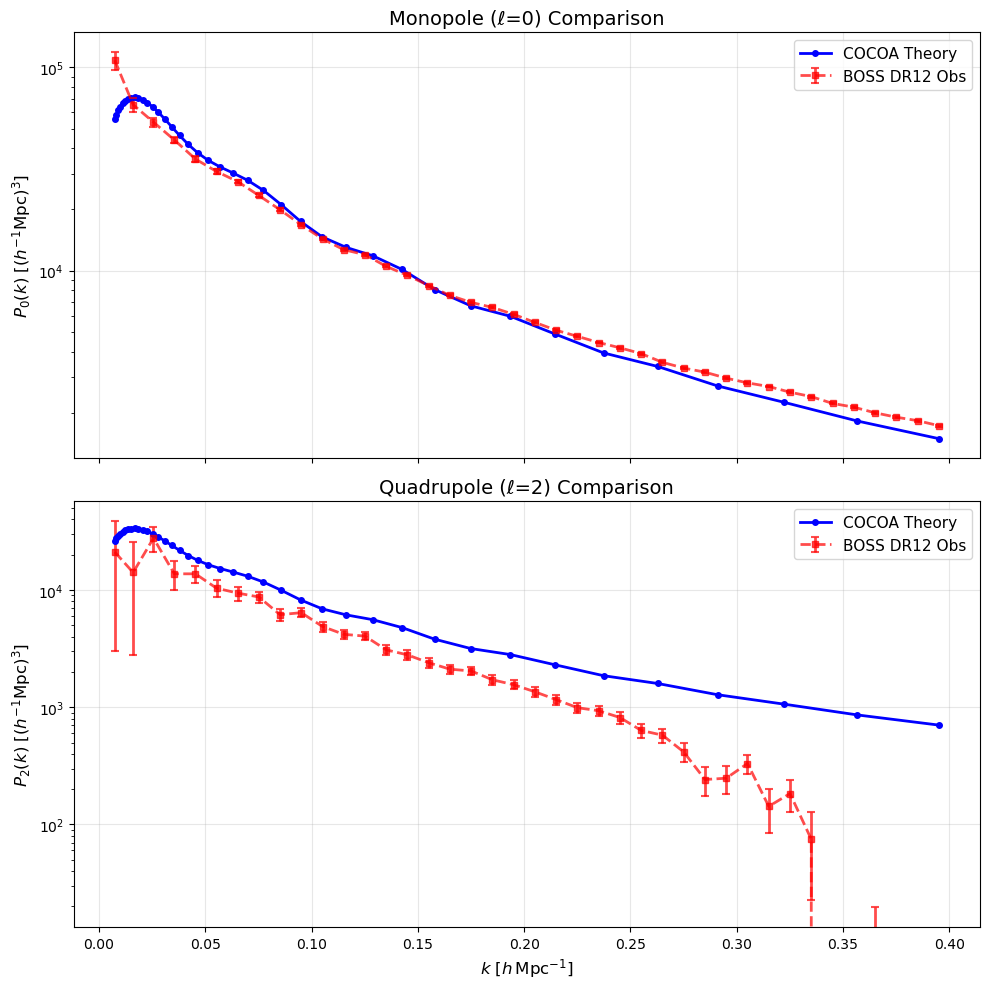

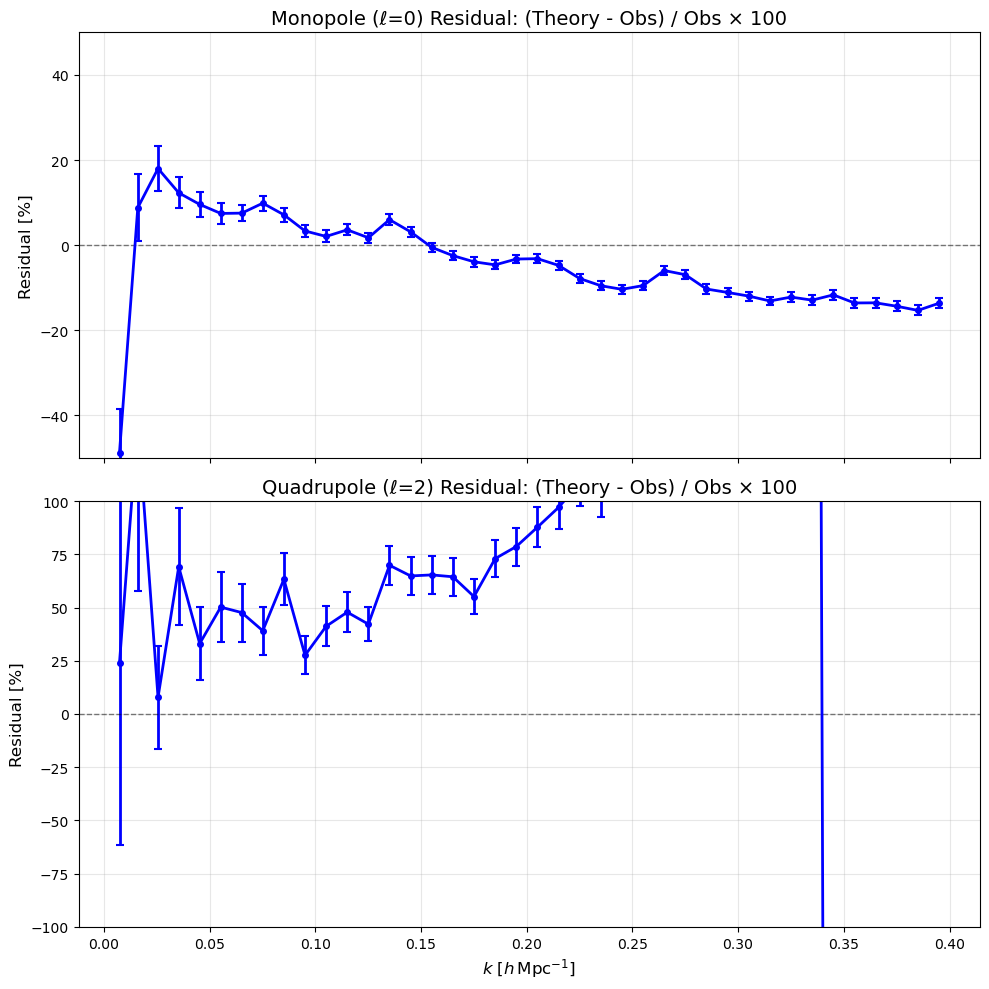

=== 統計情報 ===

Monopole (P0):
  Theory range: [1.49e+03, 7.12e+04]
  Obs range: [1.73e+03, 1.08e+05]
  Mean residual: -4.37%
  RMS residual: 12.11%
  Mean error: 6.43e+02 (4.41%)

Quadrupole (P2):
  Theory range: [7.04e+02, 3.36e+04]
  Obs range: [-1.72e+02, 2.77e+04]
  Mean residual: -67.66%
  RMS residual: 700.20%
  Mean error: 1.29e+03 (30.72%)

=== kビンの比較 ===
COCOA kビン数: 40
BOSS k-eff数: 40
COCOA k範囲: [0.007424, 0.395040]
BOSS k範囲: [0.007424, 0.395040]


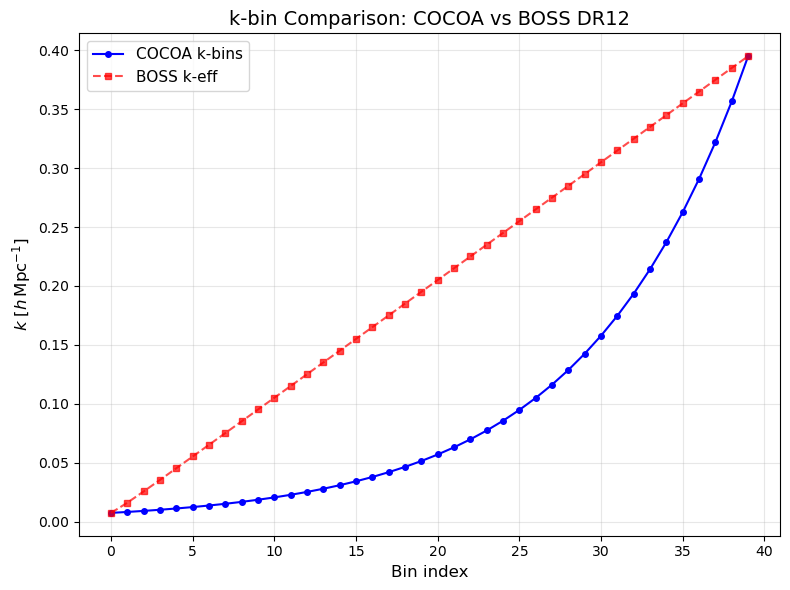

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline as iuspline

# ===== COCOAのkビン計算関数 =====
def calculate_cocoa_k_bins(k_min, k_max, Nk):
    """COCOAの対数等間隔kビンを計算"""
    log_dk = (np.log10(k_max) - np.log10(k_min)) / (Nk - 1)
    k_bins = np.array([10**(np.log10(k_min) + i * log_dk) for i in range(Nk)])
    return k_bins

# ===== 設定 =====
data_dir = "./"
theory_file = data_dir + "mg_hsc_y3_theory_kaiser_rsd_boss_dr12.modelvector"
obs_file = data_dir + "boss_dr12_cmass_datavector.txt"
boss_original_file = data_dir + "Power_Spectrum_cmass_ngc_v5.txt"
cov_file = data_dir + "boss_dr12_cmass_covariance.txt"  # 共分散行列ファイルを追加

# ===== データ読み込み =====
theory_data = np.loadtxt(theory_file)
theory_indices = theory_data[:, 0].astype(int)
theory_values = theory_data[:, 1]

obs_data = np.loadtxt(obs_file)
obs_indices = obs_data[:, 0].astype(int)
obs_values = obs_data[:, 1]

# ===== 共分散行列の読み込みとエラーバー計算 =====
# 共分散行列ファイルの形式: i j cov_value (3列)
cov_data = np.loadtxt(cov_file)
Ndata = len(obs_values)  # データベクトルのサイズ（通常80: monopole 40 + quadrupole 40）

# 共分散行列を構築
cov_matrix = np.zeros((Ndata, Ndata))
for row in cov_data:
    i, j = int(row[0]), int(row[1])
    if i < Ndata and j < Ndata:
        cov_matrix[i, j] = row[2]

# 対角要素の平方根がエラーバー（標準偏差）
errors = np.sqrt(np.diag(cov_matrix))

# ===== k値の取得 =====
k_min = 0.007424
k_max = 0.395040
Nk = 40
k_bins_cocoa = calculate_cocoa_k_bins(k_min, k_max, Nk)

k_eff = []
P0_boss_orig = []
P2_boss_orig = []
with open(boss_original_file, 'r') as f:
    for line in f:
        if line.startswith('#') or len(line.strip()) == 0:
            continue
        parts = line.split()
        if len(parts) >= 4:
            try:
                k_eff.append(float(parts[1]))
                P0_boss_orig.append(float(parts[2]))
                P2_boss_orig.append(float(parts[3]))
            except ValueError:
                continue

k_eff = np.array(k_eff)
P0_boss_orig = np.array(P0_boss_orig)
P2_boss_orig = np.array(P2_boss_orig)

# ===== データ分割 =====
theory_p0 = theory_values[:Nk] 
theory_p2 = theory_values[Nk:2*Nk]
obs_p0 = obs_values[:Nk]
obs_p2 = obs_values[Nk:2*Nk]

# エラーバーも分割
errors_p0 = errors[:Nk]
errors_p2 = errors[Nk:2*Nk]

# ===== プロット（エラーバー付き） =====
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Monopole (P0)
ax = axes[0]
ax.plot(k_bins_cocoa, theory_p0, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.errorbar(k_eff, obs_p0, yerr=errors_p0, fmt='r--', label='BOSS DR12 Obs', 
            linewidth=2, marker='s', markersize=4, alpha=0.7, capsize=3, capthick=1.5)
ax.set_ylabel(r'$P_0(k)$ [$(h^{-1}\mathrm{Mpc})^3$]', fontsize=12)
ax.set_title('Monopole (ℓ=0) Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Quadrupole (P2)
ax = axes[1]
ax.plot(k_bins_cocoa, theory_p2, 'b-', label='COCOA Theory', linewidth=2, marker='o', markersize=4)
ax.errorbar(k_eff, obs_p2, yerr=errors_p2, fmt='r--', label='BOSS DR12 Obs', 
            linewidth=2, marker='s', markersize=4, alpha=0.7, capsize=3, capthick=1.5)
ax.set_xlabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_ylabel(r'$P_2(k)$ [$(h^{-1}\mathrm{Mpc})^3$]', fontsize=12)
ax.set_title('Quadrupole (ℓ=2) Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# ===== 残差プロット（エラーバー付き） =====
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Monopole残差
ax = axes[0]
residual_p0 = (iuspline(k_bins_cocoa, theory_p0)(k_eff) - obs_p0) / obs_p0 * 100
# 残差のエラーバー（相対誤差として計算）
residual_errors_p0 = (errors_p0 / obs_p0) * 100
ax.errorbar(k_eff, residual_p0, yerr=residual_errors_p0, fmt='b-', 
            linewidth=2, marker='o', markersize=4, capsize=3, capthick=1.5)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel(r'Residual [%]', fontsize=12)
ax.set_title('Monopole (ℓ=0) Residual: (Theory - Obs) / Obs × 100', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim([-50, 50])

# Quadrupole残差
ax = axes[1]
residual_p2 = (iuspline(k_bins_cocoa, theory_p2)(k_eff) - obs_p2) / obs_p2 * 100
residual_errors_p2 = (errors_p2 / obs_p2) * 100
ax.errorbar(k_eff, residual_p2, yerr=residual_errors_p2, fmt='b-', 
            linewidth=2, marker='o', markersize=4, capsize=3, capthick=1.5)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_ylabel(r'Residual [%]', fontsize=12)
ax.set_title('Quadrupole (ℓ=2) Residual: (Theory - Obs) / Obs × 100', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim([-100, 100])

plt.tight_layout()
plt.show()

# ===== 統計情報を表示 =====
print("=== 統計情報 ===")
print(f"\nMonopole (P0):")
print(f"  Theory range: [{theory_p0.min():.2e}, {theory_p0.max():.2e}]")
print(f"  Obs range: [{obs_p0.min():.2e}, {obs_p0.max():.2e}]")
print(f"  Mean residual: {residual_p0.mean():.2f}%")
print(f"  RMS residual: {np.sqrt(np.mean(residual_p0**2)):.2f}%")
print(f"  Mean error: {errors_p0.mean():.2e} ({errors_p0.mean()/obs_p0.mean()*100:.2f}%)")

print(f"\nQuadrupole (P2):")
print(f"  Theory range: [{theory_p2.min():.2e}, {theory_p2.max():.2e}]")
print(f"  Obs range: [{obs_p2.min():.2e}, {obs_p2.max():.2e}]")
print(f"  Mean residual: {residual_p2.mean():.2f}%")
print(f"  RMS residual: {np.sqrt(np.mean(residual_p2**2)):.2f}%")
print(f"  Mean error: {errors_p2.mean():.2e} ({errors_p2.mean()/obs_p2.mean()*100:.2f}%)")

# ===== 追加: kビンの比較 =====
print(f"\n=== kビンの比較 ===")
print(f"COCOA kビン数: {len(k_bins_cocoa)}")
print(f"BOSS k-eff数: {len(k_eff)}")
print(f"COCOA k範囲: [{k_bins_cocoa.min():.6f}, {k_bins_cocoa.max():.6f}]")
print(f"BOSS k範囲: [{k_eff.min():.6f}, {k_eff.max():.6f}]")

# kビンの違いをプロット
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(range(len(k_bins_cocoa)), k_bins_cocoa, 'bo-', label='COCOA k-bins', markersize=4)
ax.plot(range(len(k_eff)), k_eff, 'rs--', label='BOSS k-eff', markersize=4, alpha=0.7)
ax.set_xlabel('Bin index', fontsize=12)
ax.set_ylabel(r'$k$ [$h\,\mathrm{Mpc}^{-1}$]', fontsize=12)
ax.set_title('k-bin Comparison: COCOA vs BOSS DR12', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()